The goal of this EDA is surface level data analysis, with a focus on churn distribution, and price sensitivity.

- is there a correlation between price/power usage, and churn?
- any noticeable patterns among inactive accounts?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

client_data = pd.read_csv('client_data.csv')
price_data = pd.read_csv('price_data.csv')

In [26]:
print(client_data.info())
print(price_data.info())
#print(client_data.describe())
#print(price_data.describe())
#print(client_data['id'].nunique())
#print(client_data['id'].count())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [ ]:
print(client_data['churn'].value_counts())
print(f'\nPercentage of active customers: {client_data['churn'].value_counts(normalize=True)[0] * 100:.2f}%')
print(f'Percentage of churned customers: {client_data['churn'].value_counts(normalize=True)[1] * 100:.2f}%')

churn
0    13187
1     1419
Name: count, dtype: int64

Percentage of active customers: 90.28%
Percentage of churned customers: 9.72%


- There are no duplicate customer ID's, **14606 unique values**
- **13187 active** (90.28%) (churn = 0), **1419 inactive** (9.72%) (churn = 1)

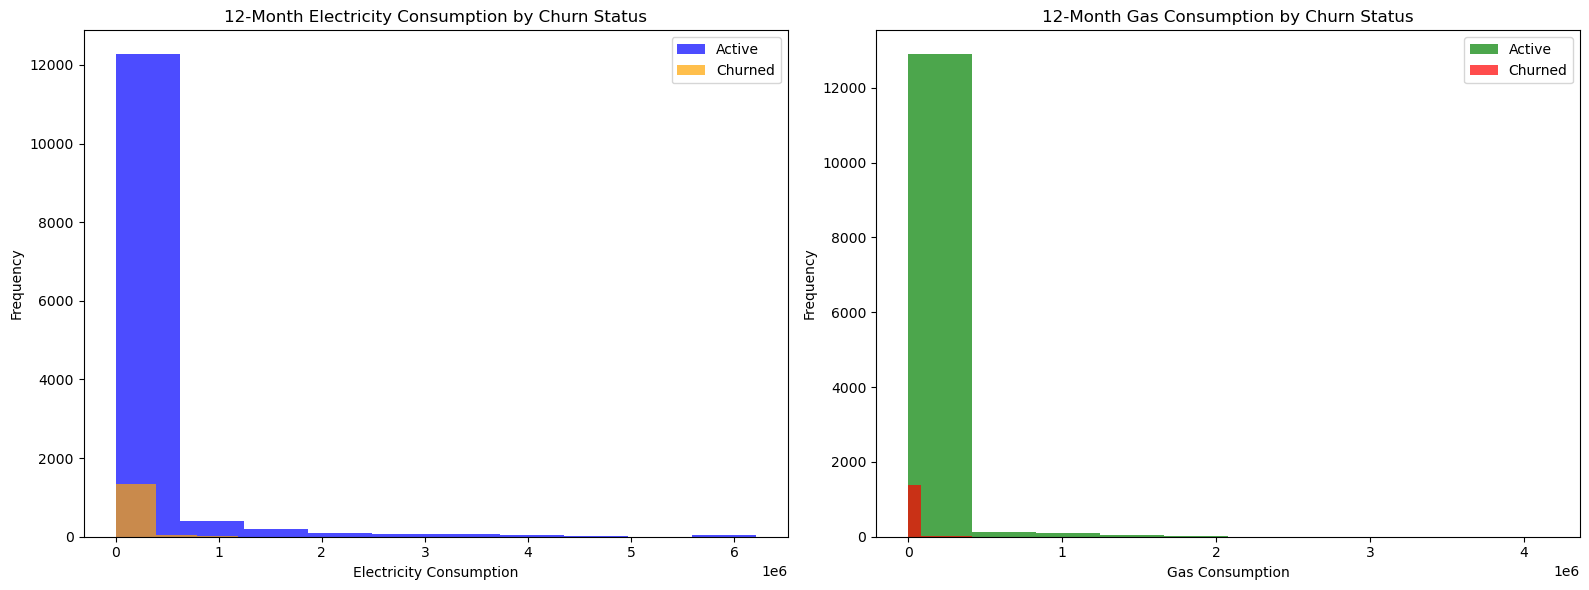

In [38]:
active = client_data[client_data['churn'] == 0]
churned = client_data[client_data['churn'] == 1]

plt.figure(figsize=(16, 6))

# electricity
plt.subplot(1, 2, 1)
plt.hist(active['cons_12m'], bins=10, alpha=0.7, label='Active', color='blue')
plt.hist(churned['cons_12m'], bins=10, alpha=0.7, label='Churned', color='orange')
plt.title('12-Month Electricity Consumption by Churn Status')
plt.xlabel('Electricity Consumption')
plt.ylabel('Frequency')
plt.legend()

# gas
plt.subplot(1, 2, 2)
plt.hist(active['cons_gas_12m'], bins=10, alpha=0.7, label='Active', color='green')
plt.hist(churned['cons_gas_12m'], bins=10, alpha=0.7, label='Churned', color='red')
plt.title('12-Month Gas Consumption by Churn Status')
plt.xlabel('Gas Consumption')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()